### Businees Context

The Ed Tech companies working on data science usually receive many
registrations for the training programs of the companies before officially
giving them a permanent role. Among those trainees, the companies want
to know which candidates are really want to work for them or will look
for a new employment after training time. This will help to reduce the
training cost, and bring higher levels of satisfaction and retention. This
work is performed to interpret the main factors impacting to candidate
decision and then build a prediction model to predict the probability of a
candidate will look for a new job or will work for the company using the
current credentials, demographics, experience data, etc.

### Objective
Ed Tech company wants to predict the likelihood of the candidates with
the intention to leave or do not leave the company after training periods. As data scientist at this Ed Tech company,you need to work on these and interpret the main factors impacting to candidate decision
and then build a prediction model to predict the probability of a candidate will
look for a new job or will work for the company using the current credentials,
demographics, experience data, etc.


### Data Description

* enrollee_id: Unique ID for the candidate

* city: City code

* city_ development _index: Development index of the city (scaled)

* gender: Gender of the candidate

* relevent_experience: Relevant experience of the candidate

* enrolled_university: Type of University course enrolled if any

* education_level: Education level of candidate

* major_discipline: Education major discipline of the candidate

* experience: Candidate total experience in years

* company_size: No of employees in current employer's company

* company_type: Type of current employer

* lastnewjob: Difference in years between previous job and current job

* training_hours: training hours completed

* target: 0 – Not looking for a job change, 1 – Looking for a job change


#### What is City Development Index?

* The City Development Index was developed for the Second United Nations Conference on Human Settlements (Habitat II) in 1996 and measures the level of development in cities. The Urban Indicators Programme of the United Nations Human Settlements Programme (UN-Habitat) developed the indicator so that they could rank cities of the world according to their level of development and as a display of indicators depicting development. The CDI cuts across the different clusters identified in the Urban Indicator Framework as it is based on five sub-indices namely, infrastructure, waste, health, education, and city product. It is useful as it provides a snap-shot view of how cities are doing concerning the different indices

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score)
from sklearn.metrics import(
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [3]:
df = pd.read_csv('jobs_data.csv')
df.head(3)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0


In [5]:
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

((19158, 14), None)

 * 8 columns have missing data

In [7]:
df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [9]:
df.describe(exclude=np.number).T

,count,unique,top,freq
city,19158,123,city_103,4355
gender,14650,3,Male,13221
relevent_experience,19158,2,Has relevent experience,13792
enrolled_university,18772,3,no_enrollment,13817
education_level,18698,5,Graduate,11598
major_discipline,16345,6,STEM,14492
experience,19093,22,>20,3286
company_size,13220,8,50-99,3083
company_type,13018,6,Pvt Ltd,9817
last_new_job,18735,6,1,8040


In [23]:
# list unique values of catergorical variables
cat_col = df.select_dtypes(exclude=np.number).columns.tolist()
cat_col.remove('city')
for column in cat_col:
    print(df[column].value_counts())
    print('-'*40)

gender
Male      13221
Female     1238
Other       191
Name: count, dtype: int64
----------------------------------------
relevent_experience
Has relevent experience    13792
No relevent experience      5366
Name: count, dtype: int64
----------------------------------------
enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64
----------------------------------------
education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64
----------------------------------------
major_discipline
STEM               14492
Humanities           669
Other                381
Business Degree      327
Arts                 253
No Major             223
Name: count, dtype: int64
----------------------------------------
experience
>20    3286
5      1430
4      1403
3      1354
6      1216
2      1127
7      1028
10      985
9       980
8   

### Checking for duplicate values

In [24]:
df.duplicated().sum()

0

### Checking for missing values

In [26]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

## EDA

In [27]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [28]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [41]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [30]:
### Function to plot distributions


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate analysis

#### Target

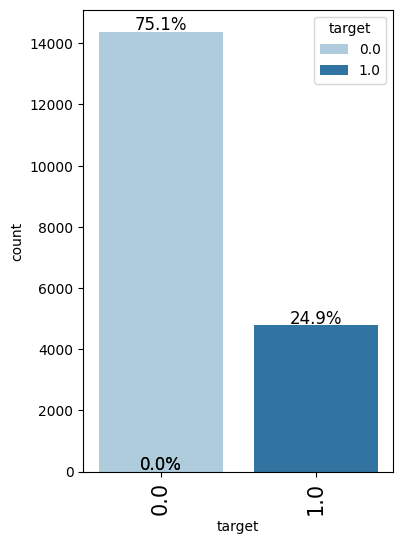

In [31]:
labeled_barplot(df, 'target', perc=True)

* Target variable is imbalanced

#### City_development_index

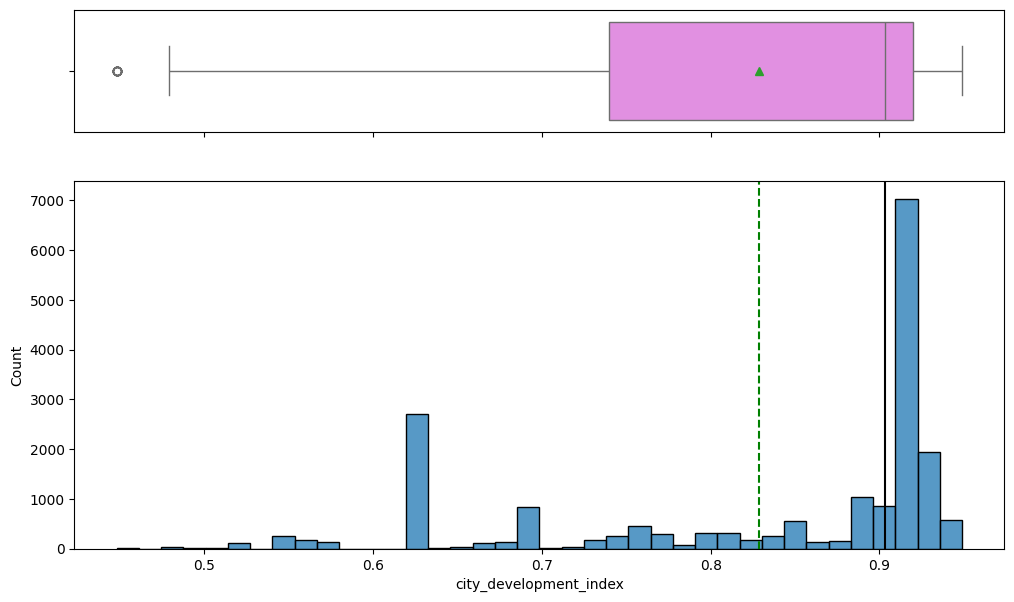

In [32]:
histogram_boxplot(df,'city_development_index')

In [33]:
df[df['city_development_index']<0.45]

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
1523,8238,city_33,0.448,NaN,Has relevent experience,Part time course,Graduate,STEM,10,50-99,NGO,>4,48,1.0
4744,30985,city_33,0.448,NaN,No relevent experience,Full time course,Graduate,STEM,2,NaN,NaN,never,43,1.0
5010,27970,city_33,0.448,Male,No relevent experience,no_enrollment,Graduate,STEM,1,NaN,NaN,never,73,1.0
5265,31194,city_33,0.448,NaN,No relevent experience,NaN,High School,NaN,5,NaN,Pvt Ltd,never,86,1.0
5567,598,city_33,0.448,NaN,Has relevent experience,Part time course,Masters,STEM,6,NaN,NaN,1,18,1.0
6127,18564,city_33,0.448,NaN,No relevent experience,Full time course,Graduate,STEM,4,NaN,Public Sector,4,32,1.0
7724,31179,city_33,0.448,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,28,0.0
7864,26838,city_33,0.448,Male,Has relevent experience,no_enrollment,Graduate,STEM,8,NaN,NaN,>4,74,0.0
9134,4858,city_33,0.448,NaN,No relevent experience,Part time course,Masters,Other,2,<10,NGO,1,23,1.0
10401,19463,city_33,0.448,Male,No relevent experience,no_enrollment,Graduate,STEM,5,10000+,Pvt Ltd,2,36,0.0


* All records with a city_deveoplment_index are from city_33

#### Training_hours

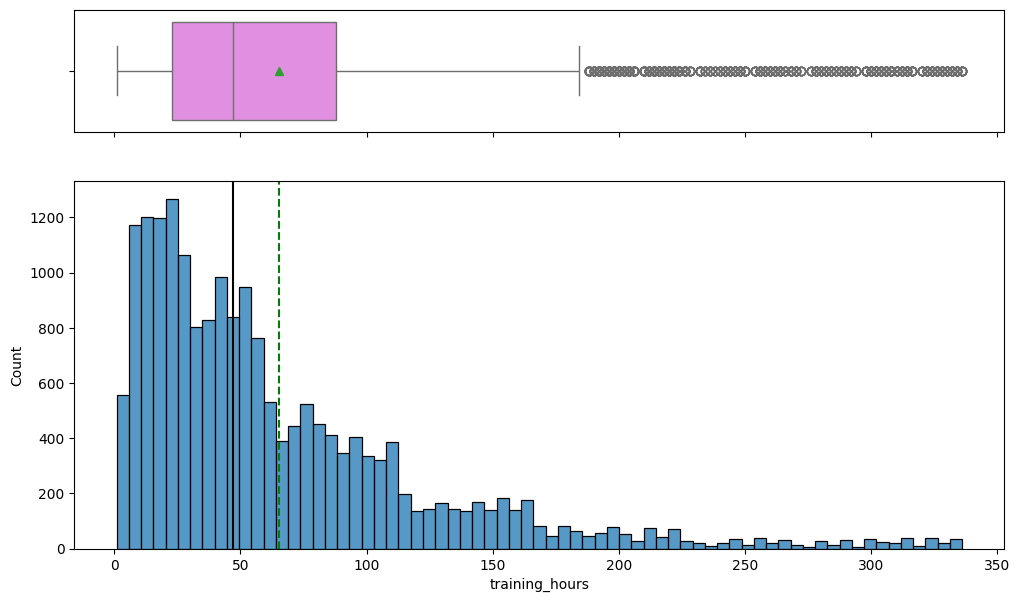

In [34]:
histogram_boxplot(df, 'training_hours')

#### Gender

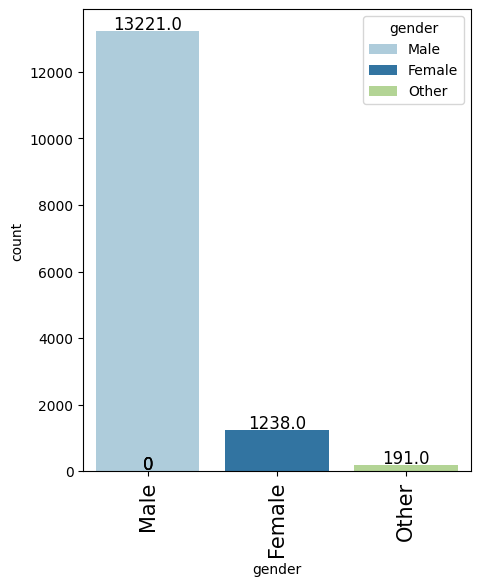

In [35]:
labeled_barplot(df, 'gender')

#### Relevent_experience

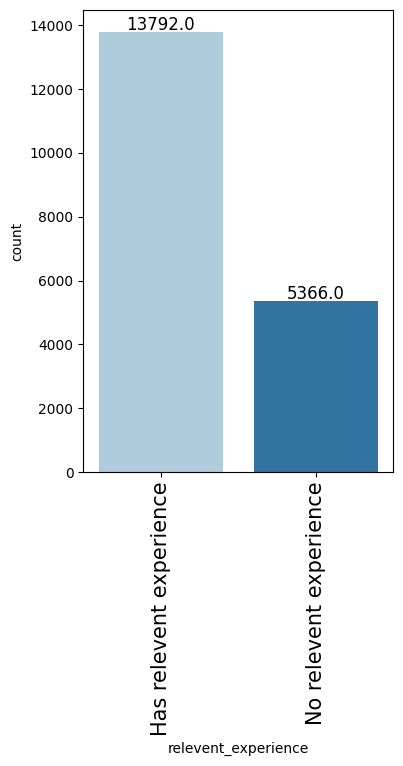

In [36]:
labeled_barplot(df, 'relevent_experience')

#### Company_size

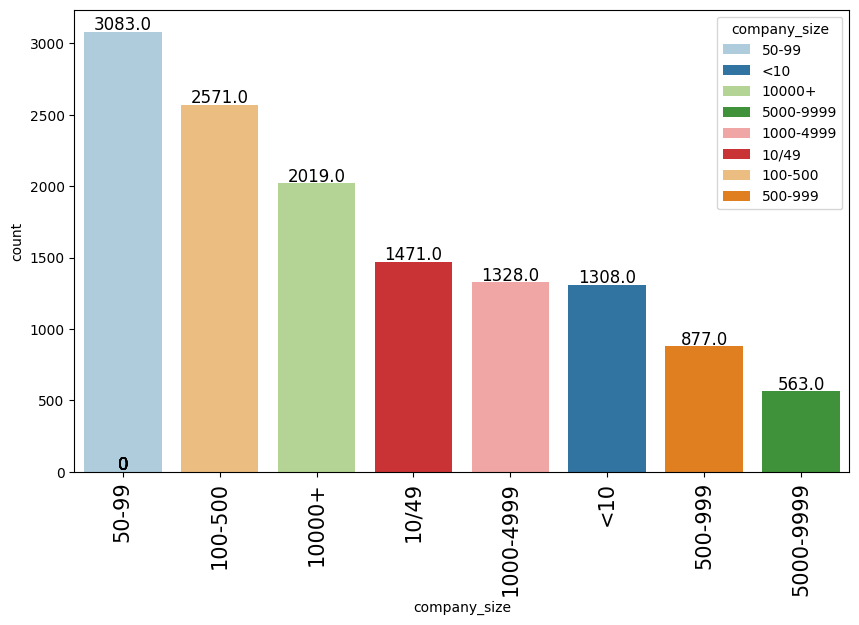

In [37]:
labeled_barplot(df,'company_size')

### Bivariate Analysis

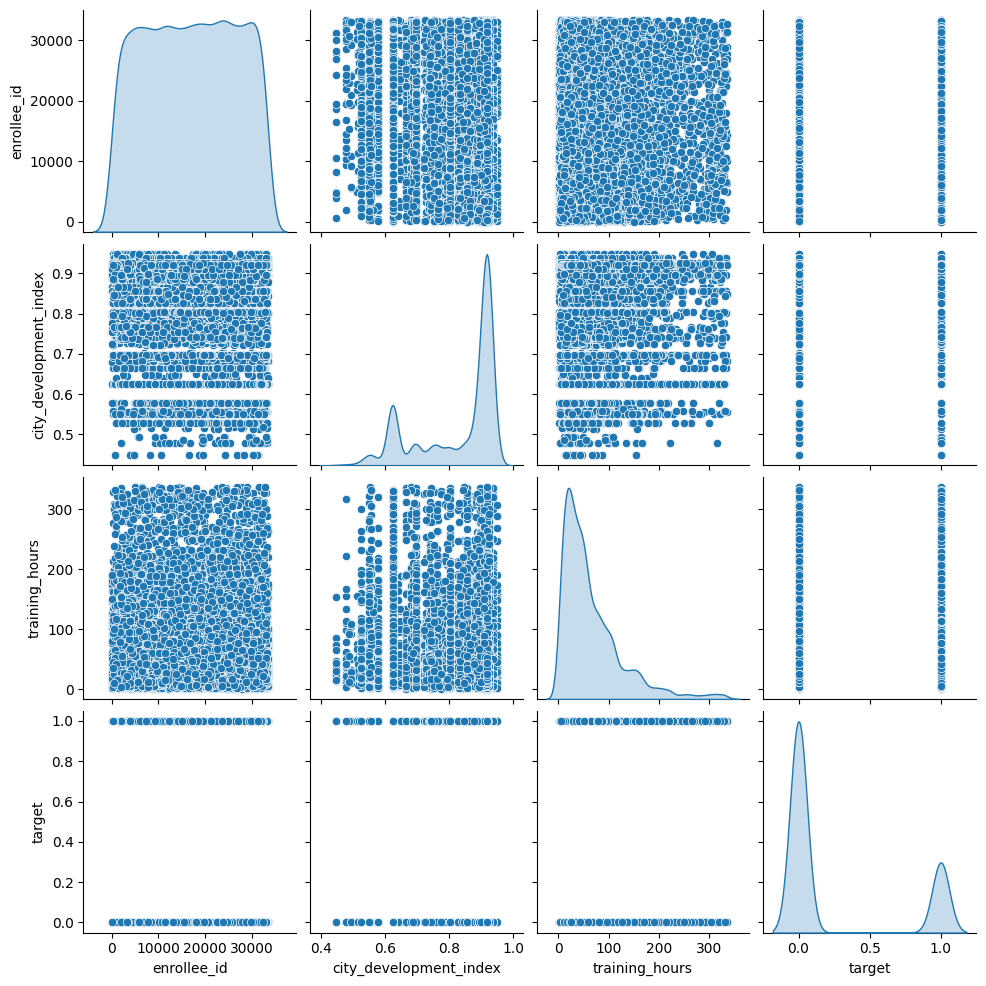

In [38]:
sns.pairplot(data=df, diag_kind='kde')
plt.show()


In [39]:
df['target'].replace(1,'yes', inplace=True)
df['target'].replace(0,'no', inplace=True)

#### Target vs gender

target     no   yes    All
gender                    
All     11262  3388  14650
Male    10209  3012  13221
Female    912   326   1238
Other     141    50    191
------------------------------------------------------------------------------------------------------------------------


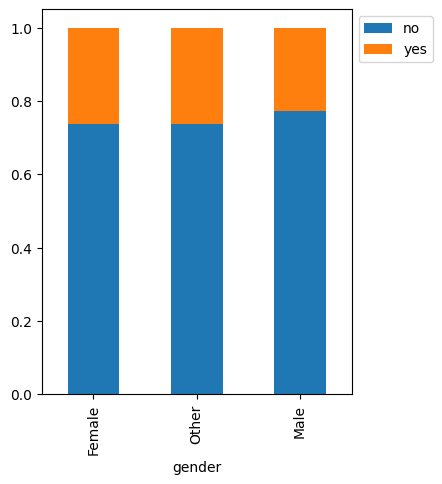

In [42]:
stacked_barplot(df, 'gender','target')

In [43]:
# Add unknown category to column
df['gender'] = df['gender'].replace(np.nan,'unknown')

target      no   yes    All
gender                     
All      14381  4777  19158
Male     10209  3012  13221
unknown   3119  1389   4508
Female     912   326   1238
Other      141    50    191
------------------------------------------------------------------------------------------------------------------------


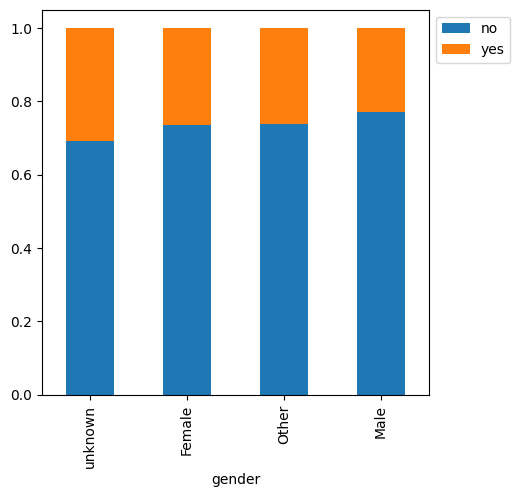

In [44]:
stacked_barplot(df,'gender','target')

#### Target vs relevent_experience

target                      no   yes    All
relevent_experience                        
All                      14381  4777  19158
Has relevent experience  10831  2961  13792
No relevent experience    3550  1816   5366
------------------------------------------------------------------------------------------------------------------------


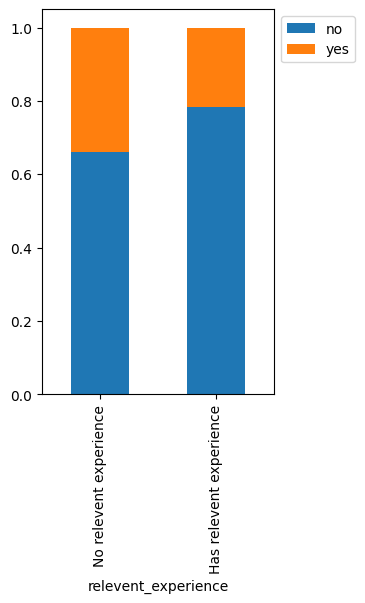

In [45]:
stacked_barplot(df, 'relevent_experience', 'target')

#### Target vs company_type

target                  no   yes    All
company_type                           
All                  10625  2393  13018
Pvt Ltd               8042  1775   9817
Public Sector          745   210    955
Early Stage Startup    461   142    603
Funded Startup         861   140   1001
NGO                    424    97    521
Other                   92    29    121
------------------------------------------------------------------------------------------------------------------------


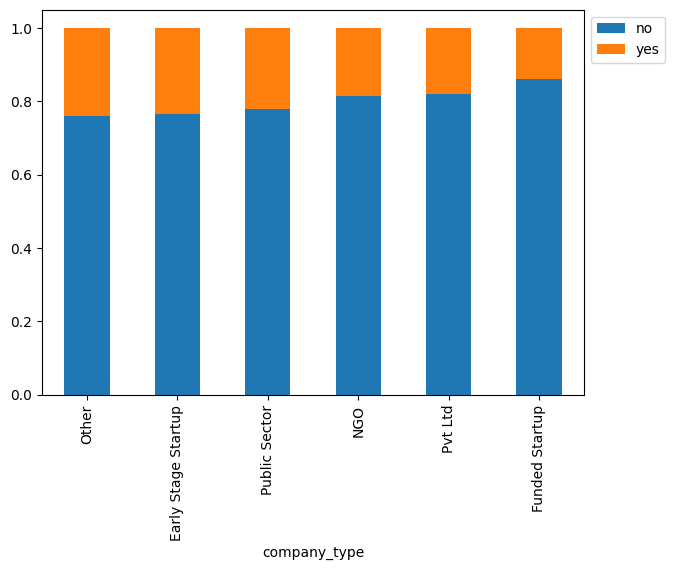

In [47]:
stacked_barplot(df,'company_type','target')

#### Target vs last_new_job

target           no   yes    All
last_new_job                    
All           14112  4623  18735
1              5915  2125   8040
never          1713   739   2452
2              2200   700   2900
>4             2690   600   3290
3               793   231   1024
4               801   228   1029
------------------------------------------------------------------------------------------------------------------------


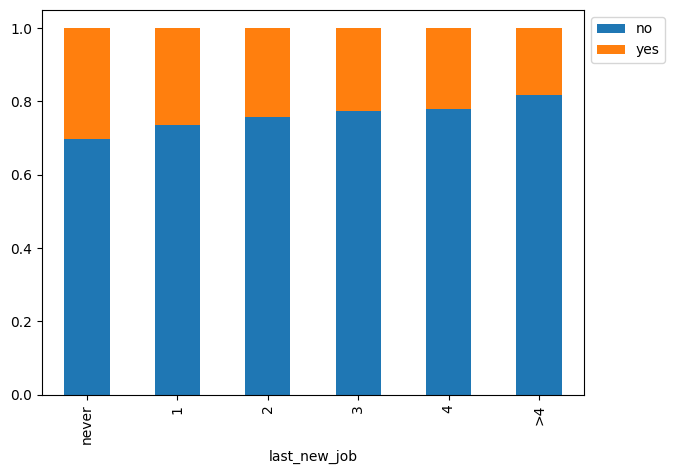

In [48]:
stacked_barplot(df, 'last_new_job', 'target')

#### Target vs training_hours

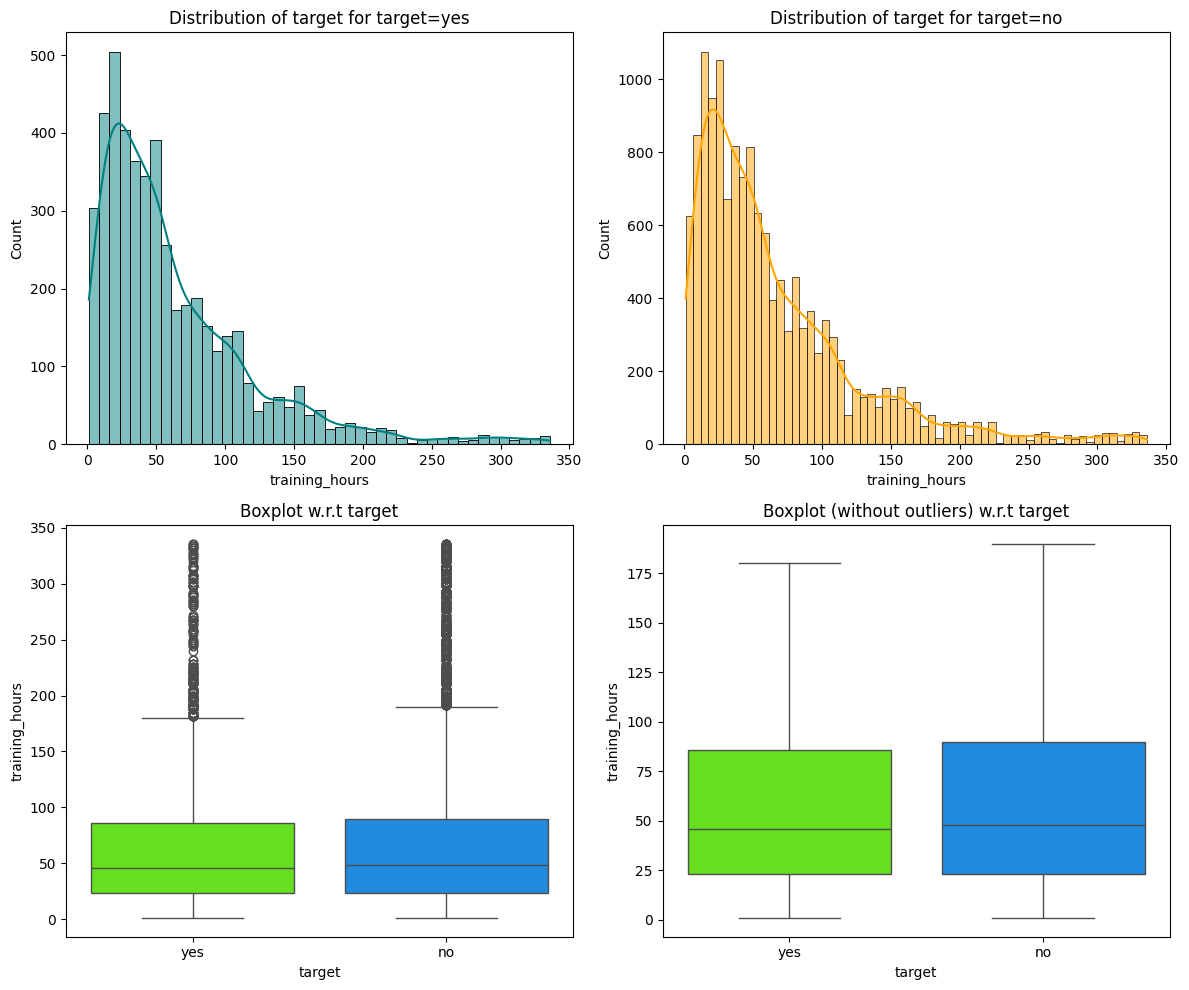

In [49]:
distribution_plot_wrt_target(df,'training_hours','target')

#### Target vs city_development_index

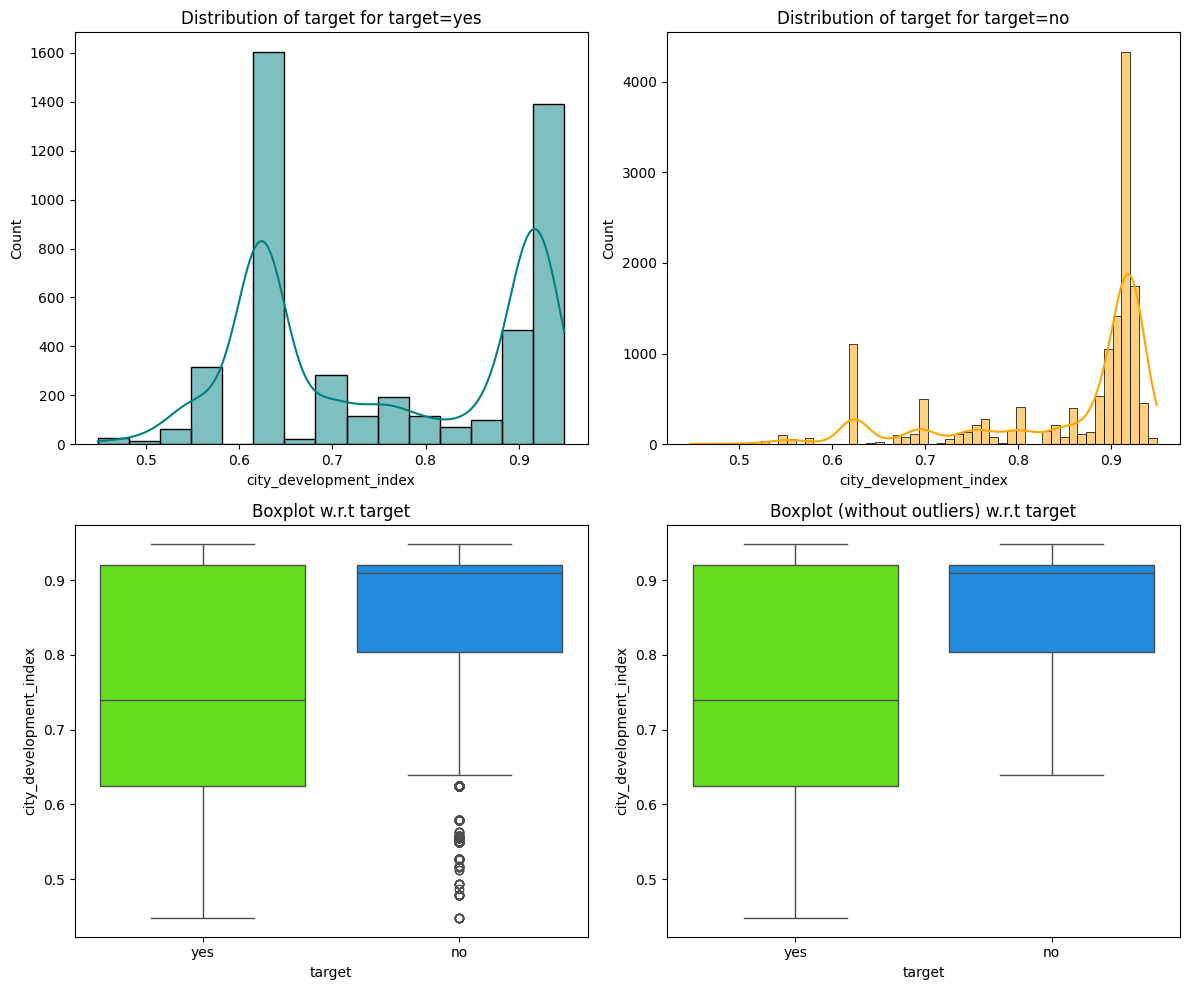

In [50]:
distribution_plot_wrt_target(df,'city_development_index','target')

## Data Preprocessing

In [51]:
df.drop(['enrollee_id'], axis=1, inplace=True)

In [53]:
df['city'].nunique()

123

In [55]:
df['city_development_index'].describe()

count    19158.000000
mean         0.828848
std          0.123362
min          0.448000
25%          0.740000
50%          0.903000
75%          0.920000
max          0.949000
Name: city_development_index, dtype: float64

In [58]:
# Discretize variable into equal-sized buckets based on quantiles
df['city'] = pd.qcut(
    df['city_development_index'],
    q=[0,0.25,0.5,1],
    labels=["Under_Developed","Developing","Developed"])

In [59]:
df['city'].value_counts()

city
Developed          9561
Under_Developed    4838
Developing         4759
Name: count, dtype: int64

In [60]:
data1 = df.copy()

In [62]:
data1.head(3)

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,Developed,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,yes
1,Developing,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,no
2,Under_Developed,0.624,unknown,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,no


# Data Preparation for Modeling

In [63]:
X = data1.drop(['target'], axis=1)
y = data1['target'].apply(lambda x: 1 if x=='yes' else 0)

In [65]:
# replacing the missing values with pandas NaN
X.fillna(pd.NA,inplace=True)

# replacing the value "unknown" with pandas NaN
X.replace(to_replace='unknown', value=pd.NA, inplace=True)

In [67]:
(X_temp, X_test,
 y_temp, y_test) = train_test_split(X,
                                    y,
                                    test_size=0.2,
                                    random_state=1,
                                    stratify=y)
(X_train, X_val,
 y_train, y_val) = train_test_split(X_temp,
                                    y_temp,
                                    test_size=0.25,
                                    random_state=1,
                                    stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)

(11494, 12) (3832, 12) (3832, 12)


In [68]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 11494
Number of rows in validation data = 3832
Number of rows in test data = 3832


In [69]:
# store the indics of train, validation, and test
train_index = set(X_train.index)
val_index = set(X_val.index)
test_index = set(X_test.index)

### Missing Value Treatment

In [70]:
X_train.isnull().sum()

city                         0
city_development_index       0
gender                    2664
relevent_experience          0
enrolled_university        217
education_level            272
major_discipline          1677
experience                  42
company_size              3566
company_type              3682
last_new_job               248
training_hours               0
dtype: int64

In [71]:
X_val.isnull().sum()

city                         0
city_development_index       0
gender                     917
relevent_experience          0
enrolled_university         85
education_level             99
major_discipline           567
experience                  13
company_size              1178
company_type              1223
last_new_job                84
training_hours               0
dtype: int64

In [72]:
X_test.isnull().sum()

city                         0
city_development_index       0
gender                     927
relevent_experience          0
enrolled_university         84
education_level             89
major_discipline           569
experience                  10
company_size              1194
company_type              1235
last_new_job                91
training_hours               0
dtype: int64

#### Impute the missing values

In [73]:
imp_mode = SimpleImputer(missing_values=pd.NA, strategy='most_frequent')

In [74]:
# we use fit() and transform() on the training set
X_train[:] = imp_mode.fit_transform(X_train[:])

In [75]:
# we use transform() ONLY on the validation and test sets
X_val[:] = imp_mode.transform(X_val[:])
X_test[:] = imp_mode.transform(X_test[:])

### Creating Dummy Variables

In [77]:
final_df = pd.concat([X_train, X_val, X_test])

#One-hot encoding the categorical variables.
final_df = pd.get_dummies(final_df, drop_first=True, dtype=int)
print(final_df.shape)

(19158, 56)


In [80]:
# using the indices of each data sets, retrieve the subsets from final_df
X_train = final_df.loc[list(train_index)]
X_val = final_df.loc[list(val_index)]
X_test = final_df.loc[list(val_index)]

In [81]:
X_val.head()

,city_development_index,training_hours,city_Developing,city_Developed,gender_Male,gender_Other,relevent_experience_No relevent experience,enrolled_university_Part time course,enrolled_university_no_enrollment,education_level_High School,...,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never
16389,0.624,98,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
8198,0.920,102,0,1,0,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,0
16391,0.795,83,1,0,1,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
8201,0.624,58,0,0,1,0,1,0,1,0,...,0,0,0,0,1,0,0,0,0,1
10,0.624,32,0,0,1,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,1


### Model evaluation criteria

**Model can make wrong predictions as:**
1. Predicting an enrollee is looking for a job change but in reality, the enrollee is not looking for a change - Loss of resources
2. Predicting an enrollee is not looking for a job change but the enrollee is looking for a job change  - Loss of opportunity

**Which case is more important?**
* Predicting an enrollee is not looking for a job change but the enrollee is looking for a job change i.e. losing on a potential candidate as the candidate will not be targeted by the HR team when he should be targeted.

**How to reduce this loss i.e need to reduce False Negatives?**
* Company would want Recall to be maximized, greater the Recall lesser the chances of false negatives.

In [82]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [83]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Model building with original data

In [87]:
lr = LogisticRegression(random_state=1).fit(X_train, y_train)

In [88]:
# Calculating different metrics on train set
log_reg_model_train_perf = model_performance_classification_sklearn(
    lr, X_train, y_train
)
print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.750653,0.0,0.0,0.0


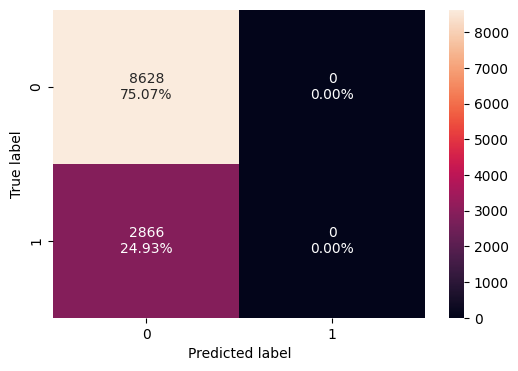

In [89]:
# creating confusion matrix
confusion_matrix_sklearn(lr, X_train, y_train)

In [90]:
# Calculating different metrics on validation set
log_reg_model_val_perf = model_performance_classification_sklearn(lr, X_val, y_val)
print("Validation performance:")
log_reg_model_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.750522,0.0,0.0,0.0


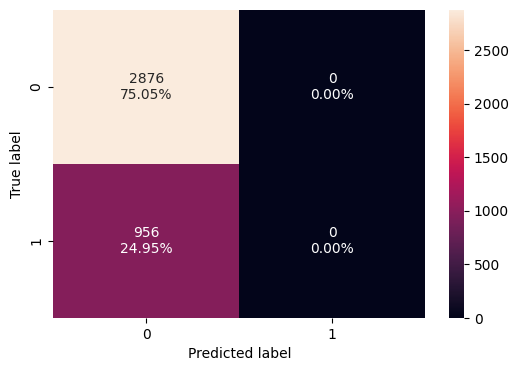

In [91]:
# creating confusion matrix
confusion_matrix_sklearn(lr, X_val, y_val)

In [92]:
y_train.value_counts()

target
0    8628
1    2866
Name: count, dtype: int64

* `y_train` is highly imbalanced with 75% values containing 0 and rest of them 1.
   - We previously checked that the target variable `y` was imbalanced in the same ratio.

#### Evaluate performance using KFold and cross_val_score

In [95]:
scoring = 'recall'
kfold = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=1)
cv_result_bfr = cross_val_score(
    estimator=lr, X=X_train, y=y_train, scoring=scoring, cv=kfold)
cv_result_bfr

array([0., 0., 0., 0., 0.])

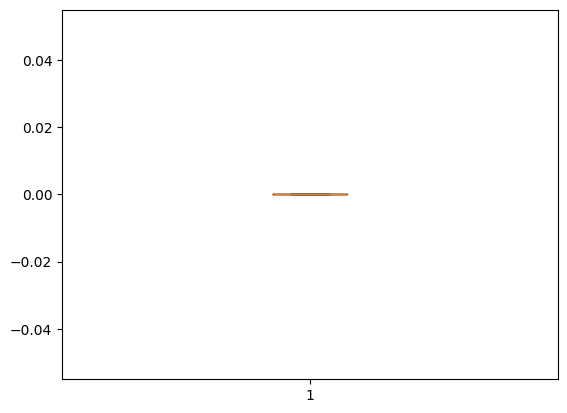

In [97]:
# Plot the CV scores of model defined above
plt.boxplot(cv_result_bfr)
plt.show()

### Model building with oversampling on training sets

In [100]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train ==1)))
print("Before Oversampling, counts of label 'No': {}\n".format(sum(y_train ==0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 2866
Before Oversampling, counts of label 'No': 8628

After Oversampling, counts of label 'Yes': 8628
After Oversampling, counts of label 'No': 8628 

After Oversampling, the shape of train_X: (17256, 56)
After Oversampling, the shape of train_y: (17256,) 



In [101]:
log_reg_over = LogisticRegression(random_state=1).fit(X_train_over,
                                                      y_train_over)

In [102]:
# Calculating different metrics on train set
log_reg_over_train_perf = model_performance_classification_sklearn(
    log_reg_over, X_train_over, y_train_over
)
print("Training performance:")
log_reg_over_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.769993,0.678373,0.830566,0.746794


In [103]:
# Calculating different metrics on validation set
log_reg_over_val_perf = model_performance_classification_sklearn(
    log_reg_over, X_val, y_val
)
print("validation performance:")
log_reg_over_val_perf

validation performance:


,Accuracy,Recall,Precision,F1
0,0.678758,0.137029,0.243948,0.175486


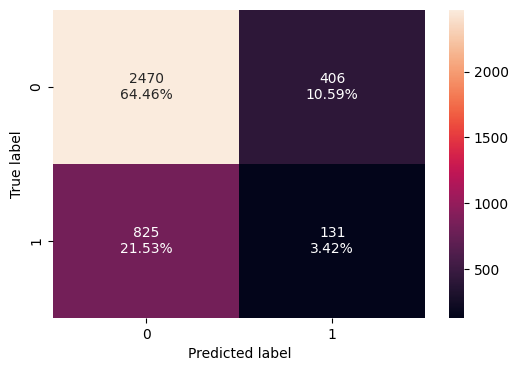

In [104]:
# creating confusion matrix
confusion_matrix_sklearn(log_reg_over, X_val, y_val)

#### Evaluate performance using KFold and cross_val_score

In [105]:
scoring = 'recall'
kfold = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=1)
cv_result_over = cross_val_score(
    estimator=log_reg_over, 
    X=X_train_over, 
    y=y_train_over,
    scoring=scoring,
    cv=kfold)
cv_result_over

array([0.67439166, 0.65681159, 0.66956522, 0.67612978, 0.68655852])

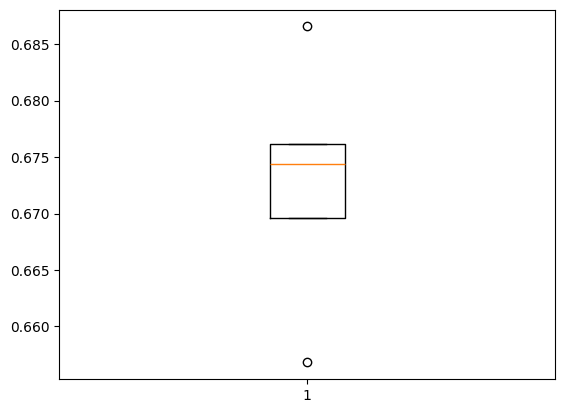

In [106]:
# Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_over)
plt.show()

### Regularization model of oversampled data

In [108]:
lr_estimator = LogisticRegression(random_state=1, solver='saga')

parameters = {'C': np.arange(0.1, 1.1, 0.1)}

grid_obj = GridSearchCV(lr_estimator, 
                        parameters, 
                        scoring='recall').fit(X_train_over, y_train_over)
lr_estimator = grid_obj.best_estimator_
lr_estimator.fit(X_train_over, y_train_over)


LogisticRegression(C=0.1, random_state=1, solver='saga')

In [109]:
# Calculating different metrics on train set
log_reg_reg_train_perf = model_performance_classification_sklearn(
    lr_estimator, X_train_over, y_train_over
)
print("Training performance:")
log_reg_reg_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.700452,0.658554,0.718786,0.687353


In [110]:
# Calculating different metrics on validation set
log_reg_reg_val_perf = model_performance_classification_sklearn(
    lr_estimator, X_val, y_val
)
print("Validation performance:")
log_reg_reg_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.63309,0.278243,0.270876,0.27451


### Model building with undersampled data on training set

In [112]:
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 2866
Before UnderSampling, counts of label '0': 8628 

After UnderSampling, counts of label '1': 2866
After UnderSampling, counts of label '0': 2866 

After UnderSampling, the shape of train_X: (5732, 56)
After UnderSampling, the shape of train_y: (5732,) 



In [113]:
log_reg_under = LogisticRegression(random_state=1).fit(X_train_un,
                                                       y_train_un)

In [114]:
# Calculating different metrics on train set
log_reg_under_train_perf = model_performance_classification_sklearn(
    log_reg_under, X_train_un, y_train_un
)
print("Training performance:")
log_reg_under_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.536462,0.528611,0.537044,0.532794


In [115]:
# Calculating different metrics on validation set
log_reg_under_val_perf = model_performance_classification_sklearn(
    log_reg_under, X_val, y_val
)
print("Validation performance:")
log_reg_under_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.516441,0.532427,0.265796,0.35458


#### Evaluate performance using KFold and cross_val_score

In [117]:
scoring = 'recall'
kfold = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=1)
cv_result_under = cross_val_score(
    estimator=log_reg_under, 
    X=X_train_un,
    y=y_train_un,
    scoring=scoring,
    cv=kfold)
cv_result_under

array([0.5095986 , 0.46341463, 0.52006981, 0.52006981, 0.53403141])

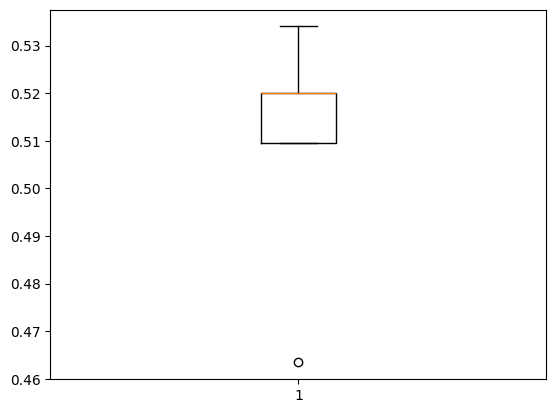

In [118]:
# Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_under)
plt.show()

* Performance of model on training set varies between 0.5 to 0.52, which is an improvement from the initial model (without oversampling)

## Model Performance Comparison and Final Model Selection

In [121]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        log_reg_over_train_perf.T,
        log_reg_reg_train_perf.T,
        log_reg_under_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Logistic Regression with oversampled data",
    "Regularized Logistic Regression",
    "Logistic Regression with undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression,Logistic Regression with oversampled data,Regularized Logistic Regression,Logistic Regression with undersampled data
Accuracy,0.750653,0.769993,0.700452,0.536462
Recall,0.000000,0.678373,0.658554,0.528611
Precision,0.000000,0.830566,0.718786,0.537044
F1,0.000000,0.746794,0.687353,0.532794


In [122]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_val_perf.T,
        log_reg_over_val_perf.T,
        log_reg_reg_val_perf.T,
        log_reg_under_val_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Logistic Regression with oversampled data",
    "Regularized Logistic Regression",
    "Logistic Regression with undersampled data",
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Logistic Regression,Logistic Regression with oversampled data,Regularized Logistic Regression,Logistic Regression with undersampled data
Accuracy,0.750522,0.678758,0.633090,0.516441
Recall,0.000000,0.137029,0.278243,0.532427
Precision,0.000000,0.243948,0.270876,0.265796
F1,0.000000,0.175486,0.274510,0.354580


* Initially, the first model used the original data without addressing imbalance issues. After applying imbalance handling techniques and regularization, recall improved from 0 to 0.52.

* Compared to other models, the model with the undersampled data performs well.

* The logistic regression model on undersampled data has given a generalized performance with the highest recall on validation data, so we will consider it as our final model

### Test Performance

In [123]:
# Calculating different metrics on validation set
log_reg_under_test_perf = model_performance_classification_sklearn(
    log_reg_under, X_test, y_test
)
print("Test performance:")
log_reg_under_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.501566,0.502618,0.250653,0.334495


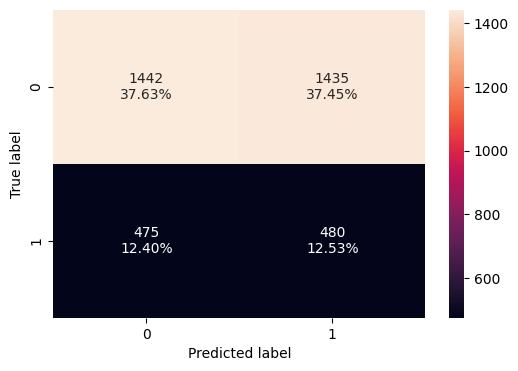

In [124]:
# creating confusion matrix
confusion_matrix_sklearn(log_reg_under, X_test, y_test)

* Model trained with undersampled data has given generalised performance on the test set

### Coefficient Interpretation

In [126]:
coef_df = pd.DataFrame(
    np.append(log_reg_under.coef_, log_reg_under.intercept_),
    index = X_train.columns.tolist() + ['Intercept'],
    columns=['Coefficients'])
coef_df.T

,city_development_index,training_hours,city_Developing,city_Developed,gender_Male,gender_Other,relevent_experience_No relevent experience,enrolled_university_Part time course,enrolled_university_no_enrollment,education_level_High School,...,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never,Intercept
Coefficients,0.054289,-0.000905,0.101122,0.009807,0.012263,-0.005362,0.137601,-0.29799,-0.13461,0.099163,...,-0.002745,0.027303,-0.091741,0.080524,-0.022879,-0.195847,-0.20994,-0.160107,-0.181293,0.064081


### Convert coefficients to odds

In [127]:
odds = np.exp(log_reg_under.coef_[0])

perc_change_odds = (np.exp(log_reg_under.coef_[0])-1)*100

odds_df = pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_train.columns).T

odds_df

,city_development_index,training_hours,city_Developing,city_Developed,gender_Male,gender_Other,relevent_experience_No relevent experience,enrolled_university_Part time course,enrolled_university_no_enrollment,education_level_High School,...,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never
Odds,1.055789,0.999096,1.106412,1.009855,1.012338,0.994652,1.147518,0.742309,0.874057,1.104246,...,1.354937,0.997259,1.027679,0.912341,1.083855,0.977381,0.822138,0.810633,0.852053,0.834191
Change_odd%,5.578929,-0.090418,10.641160,0.985504,1.233819,-0.534782,14.751767,-25.769095,-12.594298,10.424648,...,35.493656,-0.274103,2.767876,-8.765862,8.385500,-2.261915,-17.786173,-18.936675,-14.794724,-16.580913


* `city_developement_index`: Holding all other features constant a 1 unit change in city_development_index will increase the odds of a person looking for a job by ~1.05 times or a ~5.5% increase in odds of looking for a job change

* `training_hours`: Holding all other features constant a 1 unit change in training_hours will decrease the odds of a person looking for a job by ~0.99 times or a ~0.08% decrease in odds of a person looking for a job change

* `city - developing/developed`:
    * The odds of a person who is from a developing city looking for a job change is ~1.10 times more than a person who is from an under-developed city or a ~10.7% more odds than a person who is from an under-developed city.  (keeping under-developed cities as a reference).

    * Similarly, The odds of a person who is from a developed city looking for a job change is ~1.01 times more than a person who is from an under-developed city or a ~1.03% more odds than a person who is from an under-developed city (keeping under-developed cities as a reference).

* `gender - male/other` -  The odds of a male looking for a job change is ~1.16% more than a female. Similarly, The odds of a person from 'other' gender looking for a job change is ~0.52% lesser than a female. (keeping females as a reference).

* `relevent_experience` - No relevant experience: The odds of a person who has no relevant job experience looking for a job change ~1.14 times higher than the person with some relevant experience or is ~14.69% higher than a person who has some relevant experience.